In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint

import sys
init_dir = os.getcwd()

In [5]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [6]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [7]:
# Filter only consumer IDs of interest (C01)
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [8]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [16]:
consumer_df[consumer_df['total_balance'] < 0]

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id
58,2023-05-18,0.0,-149.86,C01100059
289,2023-05-11,0.0,-14.72,C01100290
820,2023-03-16,1.0,-959.84,C01100821
968,2023-04-27,0.0,-222.47,C01100969
1002,2022-10-18,0.0,-493.74,C01101003
1070,2022-06-23,0.0,-55.60,C01101071
1159,2022-02-01,0.0,-816.47,C01101160
1224,2021-04-28,0.0,-1525.74,C01101225
1275,2021-06-17,0.0,-1413.62,C01101276
1351,2022-09-21,0.0,-200.00,C01101352


In [18]:
consumer_df[consumer_df['FPF_TARGET'] == 1]

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id
174,2022-03-31,1.0,39534.66,C01100175
175,2021-08-03,1.0,33788.73,C01100176
417,2022-04-23,1.0,9472.89,C01100418
479,2021-11-29,1.0,1704.32,C01100480
783,2022-05-03,1.0,9773.72,C01100784
820,2023-03-16,1.0,-959.84,C01100821
901,2022-05-20,1.0,953.77,C01100902
1003,2022-11-03,1.0,60444.94,C01101004
1127,2023-02-03,1.0,6375.33,C01101128
1168,2023-03-03,1.0,15694.34,C01101169


In [10]:
transactions_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date
0,C01103696,2022-05-02,400.00,1.0,C01T04156275,2022-09-15
1,C01103696,2022-06-09,38.00,1.0,C01T04156276,2022-09-15
2,C01103696,2022-08-13,4.00,6.0,C01T04156277,2022-09-15
3,C01103696,2022-09-13,0.17,7.0,C01T04156278,2022-09-15
4,C01103696,2022-02-24,2095.00,1.0,C01T04156279,2022-09-15
...,...,...,...,...,...,...
4477898,C01102466,2022-08-18,120.00,6.0,C01T02770845,2022-08-22
4477899,C01102466,2022-06-16,57.46,2.0,C01T02770846,2022-08-22
4477900,C01102466,2022-01-07,2273.99,5.0,C01T02770847,2022-08-22
4477901,C01102466,2022-08-08,35.14,2.0,C01T02770848,2022-08-22


In [11]:
# Split consumers BEFORE feature engineering
train_ids, val_ids = train_test_split(
    consumer_df['masked_consumer_id'],
    test_size=0.2,
    stratify=consumer_df['FPF_TARGET'],
    random_state=42
)

train_consumers = consumer_df[consumer_df['masked_consumer_id'].isin(train_ids)]
val_consumers = consumer_df[consumer_df['masked_consumer_id'].isin(val_ids)]

train_txns = transactions[transactions['masked_consumer_id'].isin(train_ids)]
val_txns = transactions[transactions['masked_consumer_id'].isin(val_ids)]


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

# Sample function definitions for each feature
def compute_total_spending(transactions):
    return (
        transactions[transactions['amount'] < 0]
        .groupby('masked_consumer_id')['amount']
        .sum()
        .abs()
        .rename('total_spending')
        .reset_index()
    )

def compute_income_event_count(transactions):
    return (
        transactions[transactions['amount'] > 0]
        .groupby('masked_consumer_id')
        .size()
        .rename('num_income_events')
        .reset_index()
    )

def compute_spending_volatility(transactions):
    return (
        transactions[transactions['amount'] < 0]
        .groupby('masked_consumer_id')['amount']
        .std()
        .abs()
        .rename('spending_std')
        .reset_index()
    )

def compute_recent_spending(transactions, consumer_info):
    df = transactions.merge(
        consumer_info[['masked_consumer_id', 'evaluation_date']],
        on='masked_consumer_id', how='left'
    )
    df['window_start'] = df['evaluation_date'] - timedelta(days=30)
    recent = df[
        (df['amount'] < 0) & 
        (df['posted_date'] >= df['window_start'])
    ].groupby('masked_consumer_id')['amount'].sum().abs().rename('spending_last_30d').reset_index()
    return recent

def compute_risky_spending_ratio(transactions, risky_categories, consumer_info):
    df = transactions[transactions['amount'] < 0].copy()
    total = df.groupby('masked_consumer_id')['amount'].sum().abs()
    risky = df[df['category'].isin(risky_categories)].groupby('masked_consumer_id')['amount'].sum().abs()
    ratio = (risky / total).fillna(0).rename('risky_spending_ratio').reset_index()
    return ratio

# Function to apply all features
def add_all_features(consumer_df, transactions_df, risky_categories):
    dfs = [consumer_df.copy()]
    for func in [
        compute_total_spending,
        compute_income_event_count,
        compute_spending_volatility,
        lambda txns: compute_recent_spending(txns, consumer_df),
        lambda txns: compute_risky_spending_ratio(txns, risky_categories, consumer_df)
    ]:
        feat_df = func(transactions_df)
        dfs.append(feat_df)
    from functools import reduce
    return reduce(lambda left, right: pd.merge(left, right, on='masked_consumer_id', how='left'), dfs)

# Function to visualize features
def visualize_features(df, features, target_col='FPF_TARGET'):
    for feat in features:
        if df[feat].nunique() < 10:
            sns.boxplot(data=df, x=target_col, y=feat)
        else:
            sns.histplot(data=df, x=feat, hue=target_col, kde=True, stat='density', common_norm=False)
        plt.title(f'{feat} vs {target_col}')
        plt.show()

# Store in file to show user
# Remove the ace_tools import and replace with standard pandas display
import pandas as pd

# Create the DataFrame
pipeline_info = pd.DataFrame({
    "Section": ["Feature Functions", "Apply Features", "Visualize"],
    "Description": [
        "Define feature engineering functions",
        "Apply features to training and validation data",
        "Create visualizations of the features"
    ]
})

# Display the DataFrame
print("\nReusable Pipeline Code:")
print(pipeline_info.to_string())



Reusable Pipeline Code:
             Section                                     Description
0  Feature Functions            Define feature engineering functions
1     Apply Features  Apply features to training and validation data
2          Visualize           Create visualizations of the features


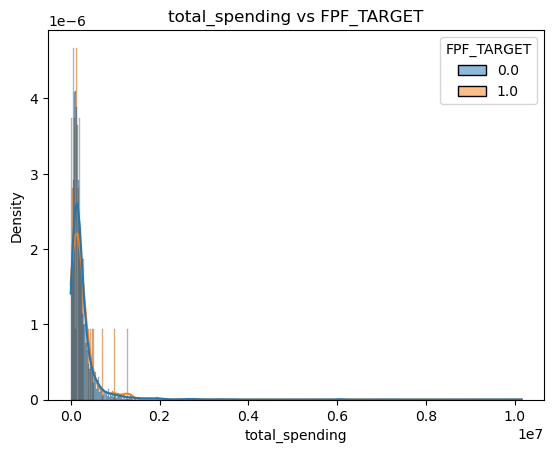

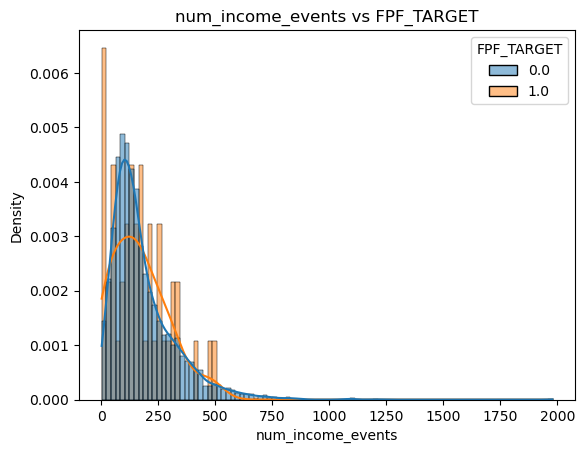

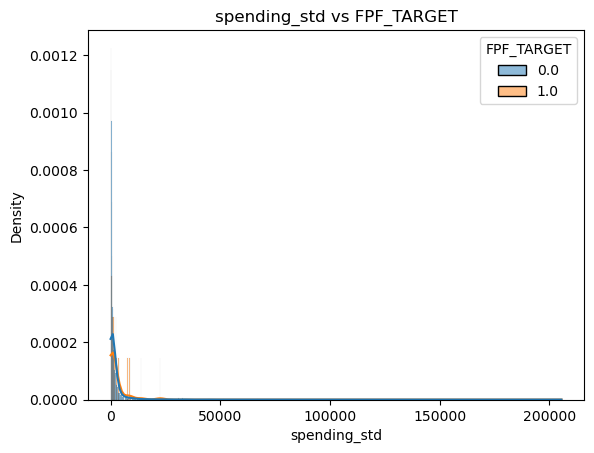

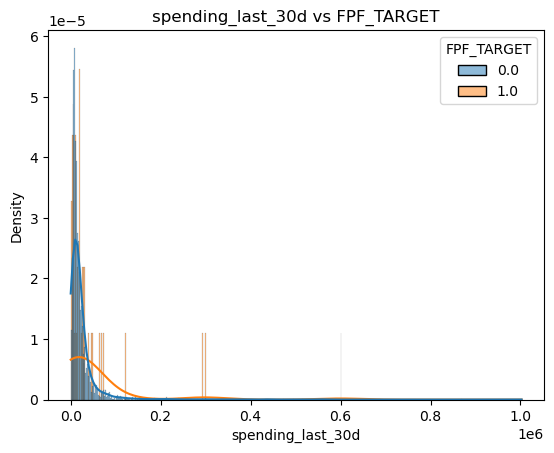

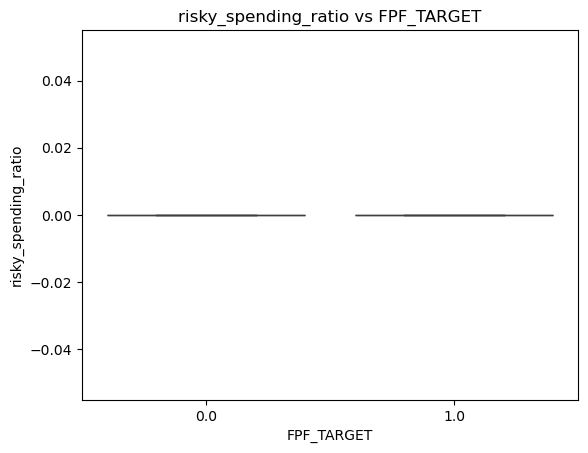

In [38]:
train_consumers_fe = add_all_features(train_consumers, train_txns, risky_categories=[5, 7])
visualize_features(train_consumers_fe, ['total_spending', 'num_income_events', 'spending_std', 'spending_last_30d', 'risky_spending_ratio'])


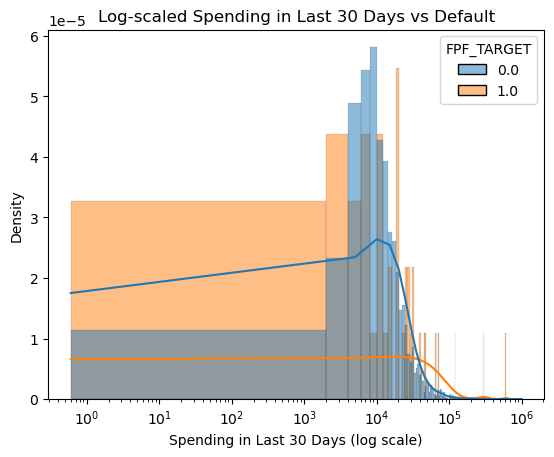

In [40]:
sns.histplot(data=train_consumers_fe, x='spending_last_30d', hue='FPF_TARGET', kde=True, stat='density', common_norm=False)
plt.xscale('log')
plt.title("Log-scaled Spending in Last 30 Days vs Default")
plt.xlabel("Spending in Last 30 Days (log scale)")
plt.show()


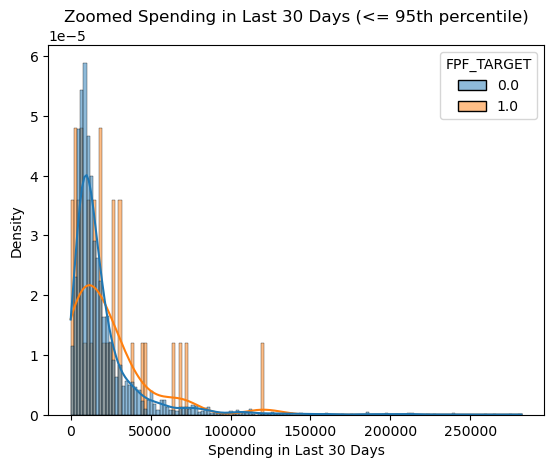

In [45]:
threshold = train_consumers_fe['spending_last_30d'].quantile(0.99)
sns.histplot(
    data=train_consumers_fe[train_consumers_fe['spending_last_30d'] <= threshold],
    x='spending_last_30d', hue='FPF_TARGET', kde=True,
    stat='density', common_norm=False
)
plt.title("Zoomed Spending in Last 30 Days (<= 95th percentile)")
plt.xlabel("Spending in Last 30 Days")
plt.show()


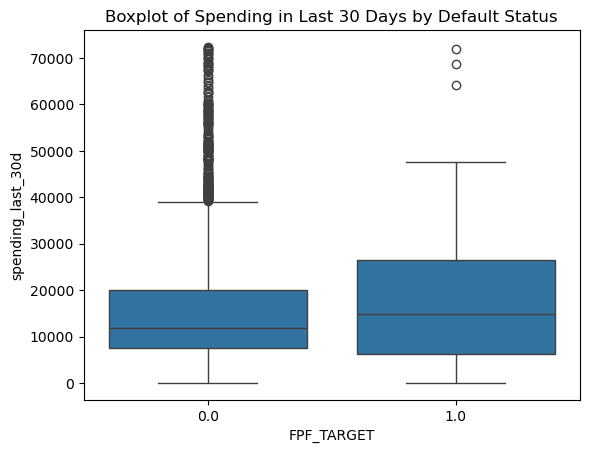

In [44]:
sns.boxplot(data=train_consumers_fe[train_consumers_fe['spending_last_30d'] <= threshold], x='FPF_TARGET', y='spending_last_30d')
plt.title("Boxplot of Spending in Last 30 Days by Default Status")
plt.show()


In [24]:
train_consumer_default = train_consumers[train_consumers['FPF_TARGET'] == 1]
train_consumer_default

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id
175,2021-08-03,1.0,33788.73,C01100176
417,2022-04-23,1.0,9472.89,C01100418
783,2022-05-03,1.0,9773.72,C01100784
820,2023-03-16,1.0,-959.84,C01100821
901,2022-05-20,1.0,953.77,C01100902
1127,2023-02-03,1.0,6375.33,C01101128
1168,2023-03-03,1.0,15694.34,C01101169
1227,2021-05-20,1.0,12432.89,C01101228
1252,2022-01-26,1.0,107271.91,C01101253
1404,2022-04-08,1.0,47.61,C01101405


In [25]:
# train_txns[train_txns['masked_consumer_id'].isin(train_consumer_default['masked_consumer_id'])]
train_txns[train_txns['masked_consumer_id'] == 'C01100176']

,masked_consumer_id,posted_date,amount,category,masked_transaction_id
187438,C01100176,2021-01-27,150.00,0.0,C01T0187438
187439,C01100176,2020-11-18,1553.00,8.0,C01T0187439
187440,C01100176,2020-10-28,901.55,4.0,C01T0187440
187441,C01100176,2020-11-13,200.00,0.0,C01T0187441
187442,C01100176,2020-10-05,650.00,4.0,C01T0187442
...,...,...,...,...,...
188568,C01100176,2021-01-14,-0.03,1.0,C01T0188568
188569,C01100176,2021-01-29,-0.20,1.0,C01T0188569
188570,C01100176,2020-12-09,-0.09,1.0,C01T0188570
188571,C01100176,2021-07-13,-14.67,16.0,C01T0188571


In [12]:
# Feature engineering
def aggregate_features(txns):
    # Create a copy of the DataFrame to avoid the warning
    txns = txns.copy()
    
    # Use .loc to properly set the new columns
    txns.loc[:, 'is_credit'] = txns['amount'] > 0
    txns.loc[:, 'is_debit'] = txns['amount'] < 0
    
    features = txns.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('amount', lambda x: x[x > 0].sum()),
        debit_sum=('amount', lambda x: x[x < 0].sum())
    )
    return features

X_train_feats = aggregate_features(train_txns)
X_val_feats = aggregate_features(val_txns)

In [30]:
X_train = X_train_feats.copy()
y_train = train_consumers.set_index('masked_consumer_id').loc[X_train.index, 'FPF_TARGET']
X_train
y_train


masked_consumer_id
C01100001    0.0
C01100003    0.0
C01100004    0.0
C01100006    0.0
C01100007    0.0
            ... 
C01104996    0.0
C01104997    0.0
C01104998    0.0
C01104999    0.0
C01105000    0.0
Name: FPF_TARGET, Length: 3200, dtype: float64

In [34]:
pd.concat([X_train, y_train], axis=1)

,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum,FPF_TARGET
masked_consumer_id,,,,,,,,,,
C01100001,-8111.42,-3.051701,645.540740,-8000.00,8483.00,-25.380,2658,276864.26,-284975.68,0.0
C01100003,2137.77,3.224389,748.056684,-4310.28,4409.40,-21.350,663,84178.75,-82040.98,0.0
C01100004,-29837.87,-27.525710,414.375001,-1800.00,1748.00,-27.555,1084,97426.62,-127264.49,0.0
C01100006,-885.47,-0.522093,670.323861,-5216.80,5462.79,-19.000,1696,197123.31,-198008.78,0.0
C01100007,-323.89,-4.261711,1091.349363,-3045.56,2856.53,-78.000,76,24358.50,-24682.39,0.0
...,...,...,...,...,...,...,...,...,...,...
C01104996,38478.08,12.384319,1634.482084,-37648.00,44100.00,-26.530,3107,470767.11,-432289.03,0.0
C01104997,591.59,0.512199,4459.475583,-56256.44,134384.01,-19.990,1155,217927.74,-217336.15,0.0
C01104998,-12120.38,-3.429649,394.044758,-1953.37,12710.00,-17.715,3534,136083.82,-148204.20,0.0


Text(0.5, 1.0, 'Distribution of feature_name by default status')

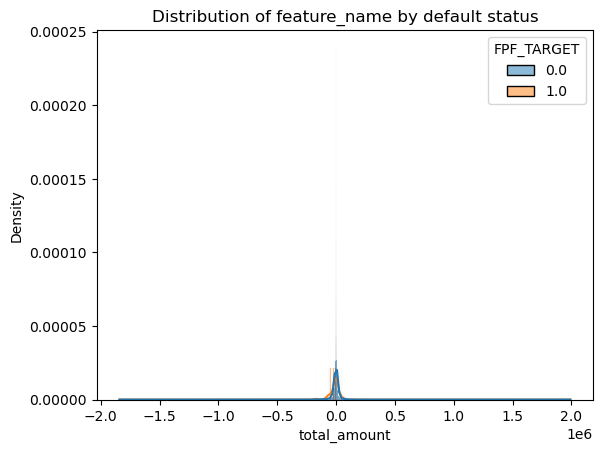

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=pd.concat([X_train, y_train], axis=1), x='total_amount', hue='FPF_TARGET', kde=True, stat="density", common_norm=False)
plt.title("Distribution of feature_name by default status")


In [32]:
X_train_feats

,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum
masked_consumer_id,,,,,,,,,
C01100001,-8111.42,-3.051701,645.540740,-8000.00,8483.00,-25.380,2658,276864.26,-284975.68
C01100003,2137.77,3.224389,748.056684,-4310.28,4409.40,-21.350,663,84178.75,-82040.98
C01100004,-29837.87,-27.525710,414.375001,-1800.00,1748.00,-27.555,1084,97426.62,-127264.49
C01100006,-885.47,-0.522093,670.323861,-5216.80,5462.79,-19.000,1696,197123.31,-198008.78
C01100007,-323.89,-4.261711,1091.349363,-3045.56,2856.53,-78.000,76,24358.50,-24682.39
...,...,...,...,...,...,...,...,...,...
C01104996,38478.08,12.384319,1634.482084,-37648.00,44100.00,-26.530,3107,470767.11,-432289.03
C01104997,591.59,0.512199,4459.475583,-56256.44,134384.01,-19.990,1155,217927.74,-217336.15
C01104998,-12120.38,-3.429649,394.044758,-1953.37,12710.00,-17.715,3534,136083.82,-148204.20


In [33]:
X_val_feats

,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum
masked_consumer_id,,,,,,,,,
C01100002,-9490.73,-3.813070,910.144154,-19150.00,20000.00,-25.290,2489,285876.77,-295367.50
C01100005,-9756.37,-4.044930,1314.772339,-6987.07,39915.16,-25.080,2412,404922.85,-414679.22
C01100013,1611.80,6.247287,646.764105,-2236.81,3407.31,-41.055,258,35574.31,-33962.51
C01100019,-18031.94,-18.608813,1051.207201,-22433.07,7205.86,-25.910,969,116338.39,-134370.33
C01100023,-323.23,-0.203674,1071.208902,-24000.00,29000.00,-11.000,1587,144844.38,-145167.61
...,...,...,...,...,...,...,...,...,...
C01104980,6005.33,4.311077,743.386392,-6000.00,22369.30,-12.830,1393,95374.09,-89368.76
C01104982,-12191.53,-5.411243,694.689372,-9000.00,11020.80,-29.750,2253,242385.22,-254576.75
C01104983,-95734.16,-75.262704,1412.169342,-10000.00,20000.00,-39.990,1272,418206.46,-513940.62


In [15]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train = pd.DataFrame(imputer.fit_transform(X_train_feats), columns=X_train_feats.columns, index=X_train_feats.index)
X_train

,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum
masked_consumer_id,,,,,,,,,
C01100001,-8111.42,-3.051701,645.540740,-8000.00,8483.00,-25.380,2658.0,276864.26,-284975.68
C01100003,2137.77,3.224389,748.056684,-4310.28,4409.40,-21.350,663.0,84178.75,-82040.98
C01100004,-29837.87,-27.525710,414.375001,-1800.00,1748.00,-27.555,1084.0,97426.62,-127264.49
C01100006,-885.47,-0.522093,670.323861,-5216.80,5462.79,-19.000,1696.0,197123.31,-198008.78
C01100007,-323.89,-4.261711,1091.349363,-3045.56,2856.53,-78.000,76.0,24358.50,-24682.39
...,...,...,...,...,...,...,...,...,...
C01104996,38478.08,12.384319,1634.482084,-37648.00,44100.00,-26.530,3107.0,470767.11,-432289.03
C01104997,591.59,0.512199,4459.475583,-56256.44,134384.01,-19.990,1155.0,217927.74,-217336.15
C01104998,-12120.38,-3.429649,394.044758,-1953.37,12710.00,-17.715,3534.0,136083.82,-148204.20


In [9]:
# Step 2: Feature Engineering
# Create debit/credit indicators
transactions_df['is_credit'] = transactions_df['amount'] > 0
transactions_df['is_debit'] = transactions_df['amount'] < 0

# Compute aggregate features
agg = transactions_df.groupby('masked_consumer_id').agg(
    total_amount=('amount', 'sum'),
    mean_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    min_amount=('amount', 'min'),
    max_amount=('amount', 'max'),
    median_amount=('amount', 'median'),
    transaction_count=('amount', 'count'),
    credit_sum=('is_credit', lambda x: transactions_df.loc[x.index, 'amount'][x].sum()),
    debit_sum=('is_debit', lambda x: abs(transactions_df.loc[x.index, 'amount'][x].sum()))
)

# Ratio of credits to debits
agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

# Recent 30-day transaction features
transactions_df['days_before_eval'] = (transactions_df['evaluation_date'] - transactions_df['posted_date']).dt.days
recent_df = transactions_df[transactions_df['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
    recent30_sum=('amount', 'sum'),
    recent30_count=('amount', 'count')
)

# Monthly cashflow volatility: std / mean
transactions_df['month'] = transactions_df['posted_date'].dt.to_period('M')
monthly_cashflow = transactions_df.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
    columns={'mean': 'monthly_mean', 'std': 'monthly_std'}
)
monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan)
monthly_stats = monthly_stats.fillna(0)

# category
cat_encode = pd.get_dummies(transactions_df, columns = ['category'], drop_first = False)
cat_encode.rename(columns = {f"category_{i}.0": f"category_{i}_mean" for i in range(36)}, inplace = True)
cat_encode_mean = cat_encode.groupby('masked_consumer_id').agg({f"category_{i}_mean": 'sum' for i in range(36)})


# weekend vs weekday transactions
transactions_df['weekday'] = transactions_df['posted_date'].dt.weekday
transactions_df['is_weekend'] = transactions_df['weekday'] >= 5

weekend_spend = transactions_df[transactions_df['amount'] > 0].groupby(['masked_consumer_id', 'is_weekend'])['amount'].sum().unstack(fill_value=0)
weekend_spend.columns = ['weekday_spending', 'weekend_spending']
weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

# Transaction frequency and span
txn_freq = transactions_df.groupby('masked_consumer_id').agg(
    unique_txn_days=('posted_date', lambda x: x.nunique()),
    txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
)
txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

# percentiles of transaction amounts
percentiles = transactions_df.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

# number of large transactions
threshold = 1000  
transactions_df['is_large'] = transactions_df['amount'].abs() > threshold
large_txns = transactions_df.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

# general trendline of monthly transactions
monthly_spend = transactions_df.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()  

def compute_monthly_trend(df):
    if df.shape[0] < 2:
        return 0 
    df = df.sort_values('month')
    x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
    y = df['amount'].values
    model = LinearRegression().fit(x, y)
    return model.coef_[0] 
monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

# Merge all features
features_df = consumer_df.set_index('masked_consumer_id') \
    .join(agg, how='left') \
    .join(recent_df, how='left') \
    .join(monthly_stats, how='left') \
    .join(cat_encode_mean, how='left') \
    .join(txn_freq, how='left') \
    .join(weekend_spend, how='left') \
    .join(large_txns, how='left') \
    .join(monthly_trend, how='left') \
    .fillna(0)

/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_37485/2566243800.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_df['is_credit'] = transactions_df['amount'] > 0
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_37485/2566243800.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_df['is_debit'] = transactions_df['amount'] < 0
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_37485/2566243800.py:24: SettingWithCopyWarning: 
A value is trying to be set

In [10]:
from sklearn.metrics import classification_report
# Step 3: Train-Test Split

X = features_df.drop(columns=['FPF_TARGET', 'evaluation_date'])
y = features_df['FPF_TARGET']
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)
# Step 4: Pipeline with Imputation and Logistic Regression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, random_state=42,  max_depth = 3))
])

pipeline.fit(X_train, y_train)
y_train_pred = pipeline.predict_proba(X_train)[:, 1]
y_val_pred = pipeline.predict_proba(X_val)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred) 
val_auc = roc_auc_score(y_val, y_val_pred)
print(f"Train AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")


Train AUC: 1.0000, Validation AUC: 0.7449


<Axes: >

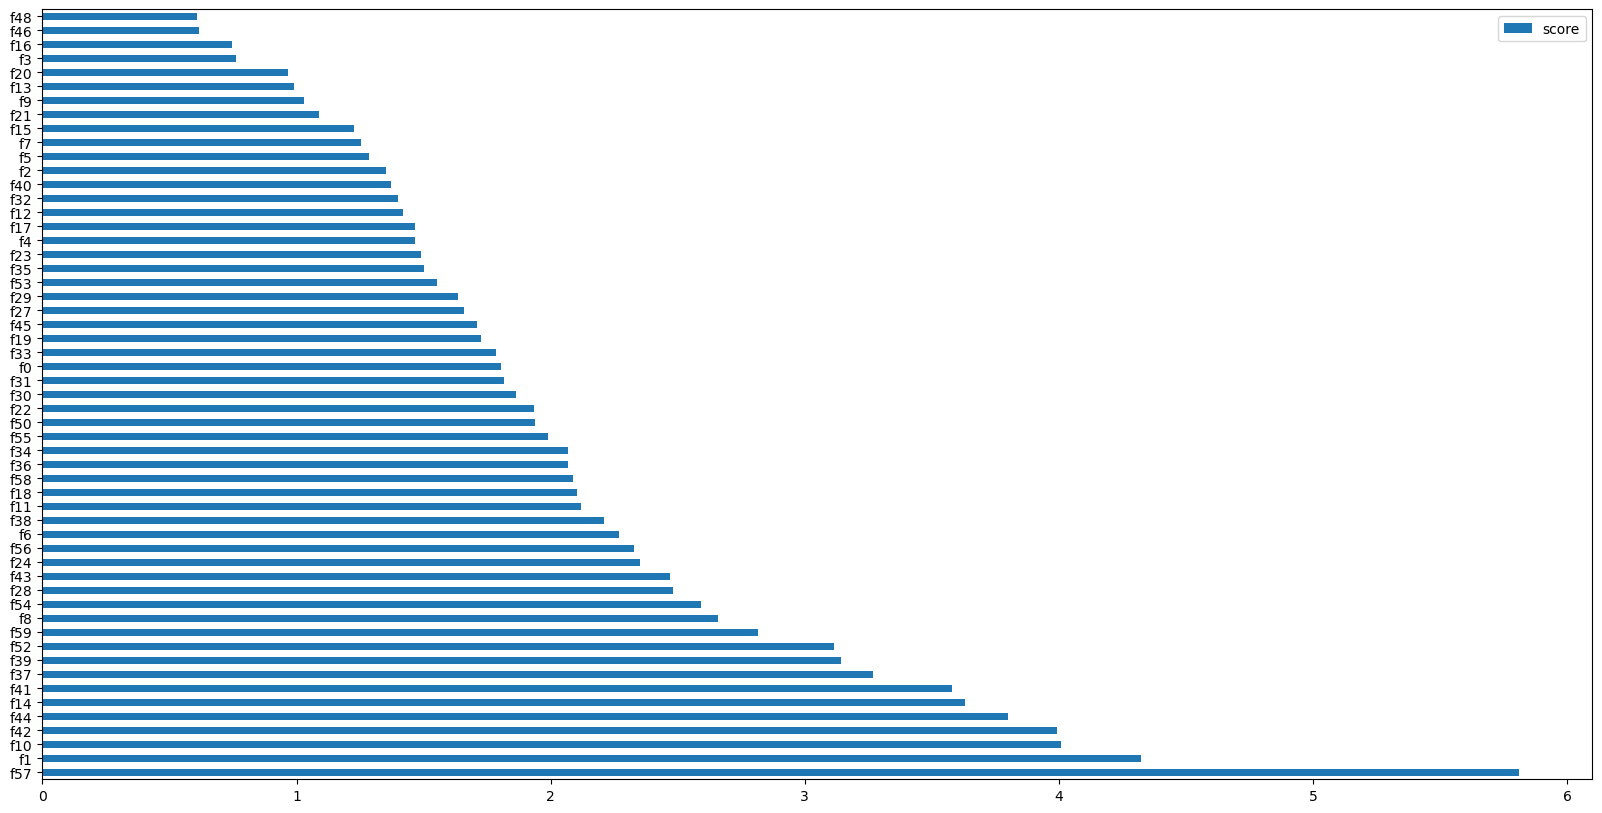

In [11]:
feature_important = pipeline['model'].get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(60, columns="score").plot(kind='barh', figsize = (20,10)) 

In [12]:
for x in data.index:
    print(X_train.columns[int(x[1:])]) 

weekend_ratio
total_amount
credit_debit_ratio
category_26_mean
category_28_mean
monthly_std
category_25_mean
category_21_mean
category_23_mean
unique_txn_days
monthly_spend_trend
credit_sum
txn_per_day
category_12_mean
category_27_mean
category_8_mean
weekend_spending
median_amount
category_22_mean
recent30_sum
category_2_mean
large_txn_count
category_20_mean
category_18_mean
weekday_spending
category_34_mean
category_6_mean
category_14_mean
category_15_mean
total_balance
category_17_mean
category_3_mean
category_29_mean
category_11_mean
category_13_mean
txn_days_span
category_19_mean
category_7_mean
min_amount
category_1_mean
recent30_count
category_16_mean
category_24_mean
mean_amount
max_amount
transaction_count
monthly_cv
category_5_mean
debit_sum
monthly_mean
category_4_mean
std_amount
category_0_mean
category_30_mean
category_32_mean


In [13]:
trans_cats = pd.read_csv("transaction_categories.csv")
trans_cats

,code,description
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


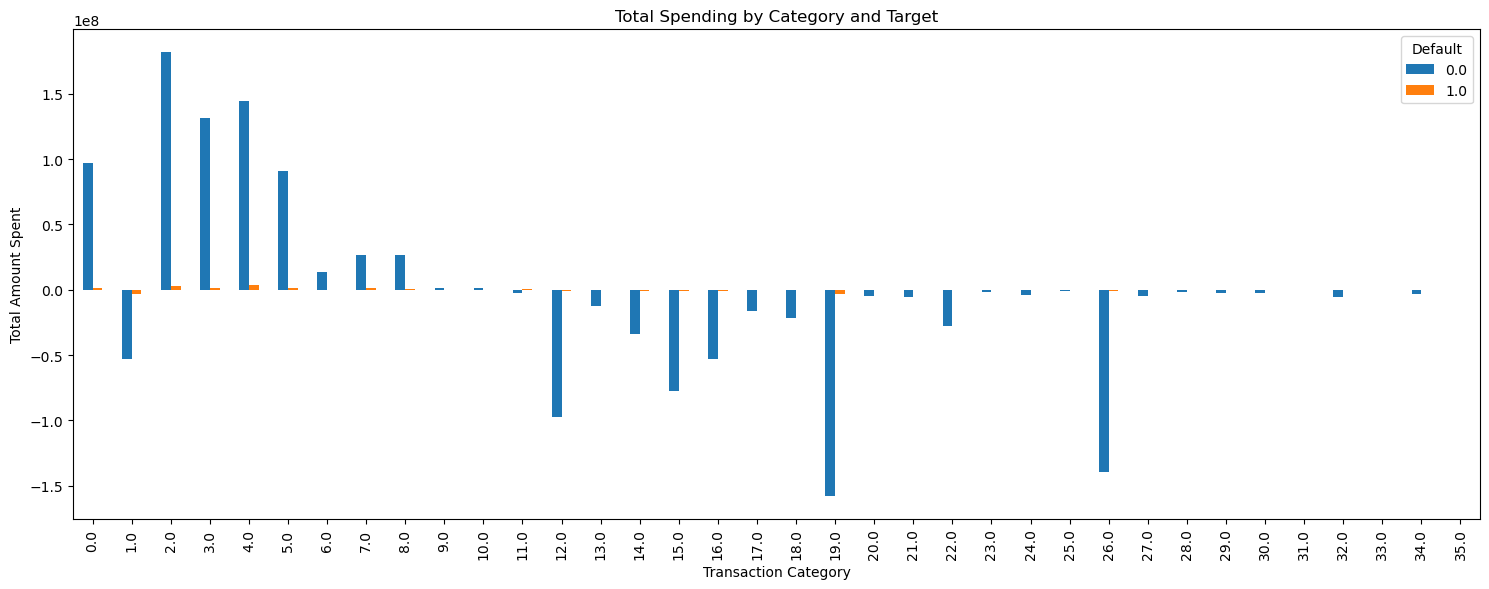

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge consumer_df with transaction_df
df = transactions_df.merge(consumer_df[['masked_consumer_id', 'FPF_TARGET']], on='masked_consumer_id')

# Total amount per category by target
category_summary = df.groupby(['category', 'FPF_TARGET'])['amount'].sum().unstack().fillna(0)
category_summary.plot(kind='bar', figsize=(15,6))
plt.title("Total Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Total Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()
